<a href="https://colab.research.google.com/github/zhanglihld-sys/Emotion-Engine/blob/main/Copy_of_Emotion_Engine.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
🔴 PANIC

Date: 2026-03-06

Sentiment Index: 12.0
Score: -38.0

SPY 673.05
VIX 26.68
VVIX 126.47
MOVE 74.53
VIX9D 27.25
VIX3M 25.73

HY_OAS 3.00
BBB_OAS 1.04
ANFCI -0.530

PANIC_WINDOW_OPEN = True
GREED_WINDOW_OPEN = False

Market Stress Score: 100.0  |  Level: EXTREME

AI Market Narrative:
Defensive tone dominates; capital preservation prioritized.

RUN_ID: 2026-03-06 20:24:19 ET
latest file: /content/drive/MyDrive/emotion_push/latest.txt
push file: /content/drive/MyDrive/emotion_push/push.txt | wrote: True
version file: /content/drive/MyDrive/emotion_push/version.txt
dashboard saved: /content/drive/MyDrive/emotion_push/dashboard.png


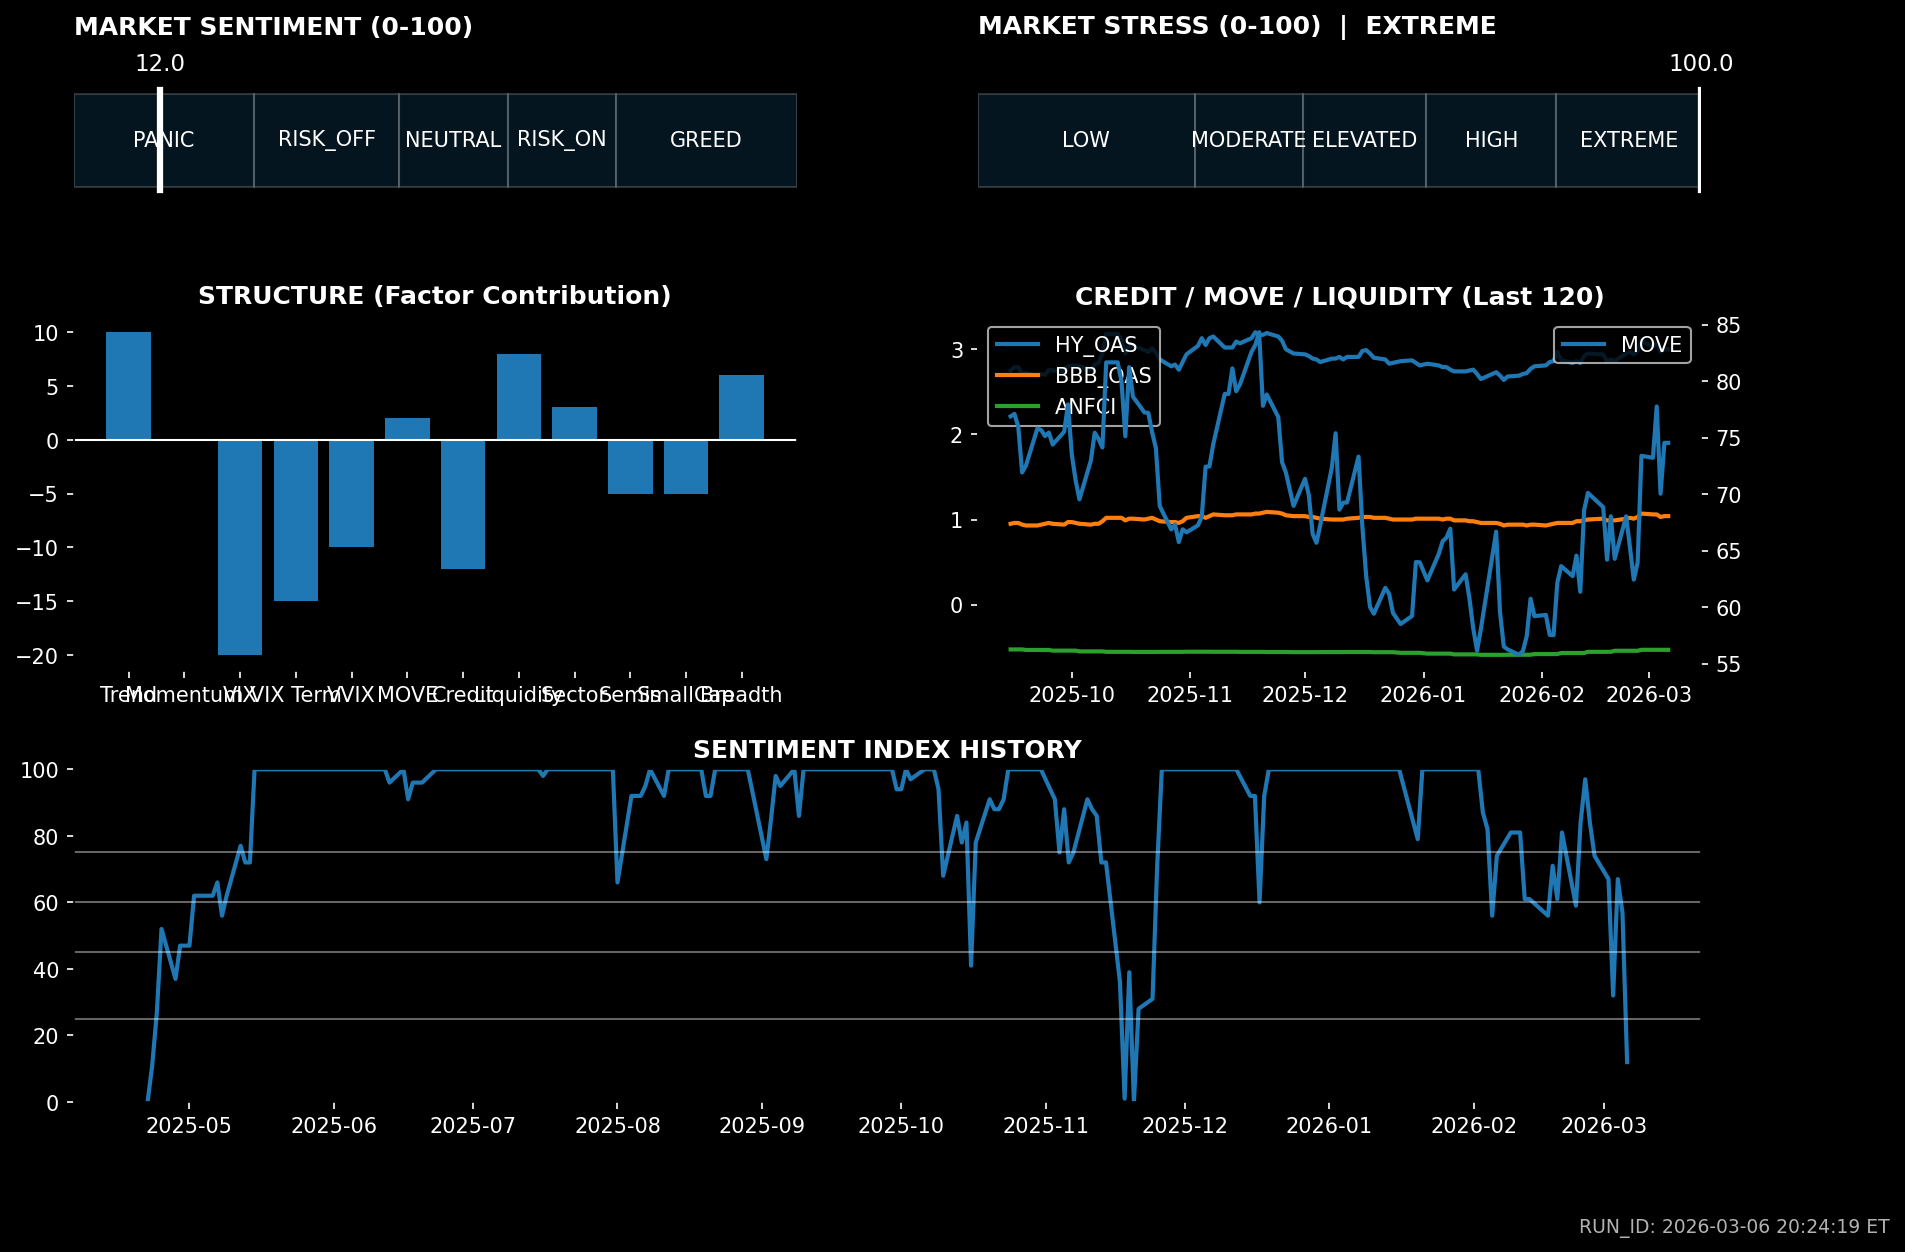

In [ ]:
# @title
# ==========================================================
# EMOTION ENGINE v5.4 — FINAL ONE-CELL (Liquidity Upgrade)
# - Adds Liquidity via FRED: ANFCI (Chicago Fed Adjusted NFCI)
# - Yahoo + FRED (HY/BBB OAS + ANFCI)
# - Sentiment (0-100) + Stress (0-100)
# - PANIC/GREED window logic
# - Bloomberg-style dashboard: gauges + structure + key stats + history + credit/move/liquidity
# - Writes:
#   - latest.txt (always)
#   - dashboard.png (always)
#   - version.txt (always)
#   - push.txt (only when panic/greed window opens)
# ==========================================================

!pip -q install yfinance fredapi pandas numpy matplotlib

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from fredapi import Fred
from datetime import datetime
from google.colab import drive
from matplotlib.gridspec import GridSpec
from IPython.display import display, Image

# =========================
# 0) USER SETTINGS (ONLY EDIT THESE TWO LINES)
# =========================
os.environ["FRED_API_KEY"] = "5009202033317512b491dec7ab372e12"   # <-- replace with your real key (32 lower-case)
EXPORT_DIR = "/content/drive/MyDrive/emotion_push/"

# =========================
# 1) CONSTANTS (DO NOT EDIT)
# =========================
ENGINE_VERSION = "Emotion Engine v5.4 FINAL ONE-CELL + LIQUIDITY(ANFCI)"

HIST_LOOKBACK_DAYS = 220

# Sentiment regime thresholds
PANIC_TH   = 25
RISKOFF_TH = 45
NEUTRAL_TH = 60
RISKON_TH  = 75
GREED_TH   = 80

# Panic confirmation (short-term stress / event risk)
PANIC_VIX_LEVEL = 28
PANIC_VIX_MIN   = 24
PANIC_SI_MAX    = 30

# Stress level thresholds (rare EXTREME)
STRESS_EXTREME = 80
STRESS_HIGH    = 62
STRESS_ELEV    = 45
STRESS_MOD     = 30

# De-saturation tweaks (your confirmed fixes)
TERM_HALF = 0.5  # add_term *= 0.5
VIX_TIER = {"28": 10, "24": 4, "20": 1}  # reduced vix tier add-on

# Liquidity scoring (ANFCI)
# ANFCI < 0 => easier conditions; ANFCI > 0 => tighter conditions
# Keep weights modest to avoid overpowering vol/credit.
ANFCI_EASY_STRONG = -0.50
ANFCI_EASY_MILD   =  0.00
ANFCI_TIGHT_MILD  =  0.25
ANFCI_TIGHT_STRONG=  0.50

# =========================
# 2) MOUNT DRIVE + PATHS
# =========================
drive.mount("/content/drive")
os.makedirs(EXPORT_DIR, exist_ok=True)

LATEST_TXT  = os.path.join(EXPORT_DIR, "latest.txt")       # always
PUSH_TXT    = os.path.join(EXPORT_DIR, "push.txt")         # alert-only
DASH_PNG    = os.path.join(EXPORT_DIR, "dashboard.png")    # always
VERSION_TXT = os.path.join(EXPORT_DIR, "version.txt")      # always

# =========================
# 3) DOWNLOAD YAHOO DATA
# =========================
tickers = [
    "SPY","QQQ","IWM","DIA",
    "^VIX","^VIX3M","^VIX9D","^VVIX",
    "^MOVE",
    "TLT","HYG",
    "XLF","XLI","XLK","SMH"
]

data = yf.download(
    tickers,
    period="12mo",
    interval="1d",
    auto_adjust=True,
    progress=False
)

if data is None or len(data) == 0:
    raise RuntimeError("Yahoo Finance download failed (empty).")

close = data["Close"].copy()

# Use SPY as master trading calendar
spy_raw = close.get("SPY", pd.Series(dtype=float)).dropna()
if spy_raw.empty:
    raise RuntimeError("Missing SPY data from Yahoo Finance.")
idx = spy_raw.index

def align(sym: str) -> pd.Series:
    s = close.get(sym, pd.Series(dtype=float))
    if s is None or len(s) == 0:
        return pd.Series(index=idx, dtype=float)
    return s.reindex(idx).ffill()

spy   = align("SPY")
qqq   = align("QQQ")
iwm   = align("IWM")
dia   = align("DIA")

vix   = align("^VIX")
vix3m = align("^VIX3M")
vix9d = align("^VIX9D")
vvix  = align("^VVIX")
move  = align("^MOVE")

tlt   = align("TLT")
hyg   = align("HYG")

xlf   = align("XLF")
xli   = align("XLI")
xlk   = align("XLK")
smh   = align("SMH")

def ma(s: pd.Series, n: int) -> pd.Series:
    return s.rolling(n).mean()

# =========================
# 4) FRED (SAFE) — Credit + Liquidity
# =========================
FRED_API_KEY = os.environ.get("FRED_API_KEY", "").strip()
fred = None
if FRED_API_KEY:
    try:
        fred = Fred(api_key=FRED_API_KEY)
    except Exception as e:
        print("FRED init failed, will fallback:", e)
        fred = None

def fred_series_to_idx(series_id: str, idx: pd.DatetimeIndex) -> pd.Series:
    if fred is None:
        return pd.Series(index=idx, dtype=float)
    try:
        s = fred.get_series(series_id)
        s.index = pd.to_datetime(s.index)
        s = s.reindex(idx).ffill()
        return pd.to_numeric(s, errors="coerce")
    except Exception as e:
        print(f"FRED fetch failed for {series_id}, fallback:", str(e)[:120])
        return pd.Series(index=idx, dtype=float)

# Credit spreads (percent units)
hy_oas  = fred_series_to_idx("BAMLH0A0HYM2", idx)
bbb_oas = fred_series_to_idx("BAMLC0A4CBBB", idx)

# Liquidity: Chicago Fed Adjusted NFCI
anfci = fred_series_to_idx("ANFCI", idx)

# Credit fallback proxy (if FRED missing)
credit_proxy = (hyg / tlt).replace([np.inf, -np.inf], np.nan)

# =========================
# 5) COMPONENT ENGINE (now includes Liquidity)
# =========================
def liquidity_score_at(i: int) -> int:
    """ANFCI-based liquidity score. Higher = easier conditions (risk-supportive)."""
    a = anfci.iloc[i]
    if not pd.notna(a):
        return 0
    if a <= ANFCI_EASY_STRONG:
        return +8
    elif a < ANFCI_EASY_MILD:
        return +4
    elif a >= ANFCI_TIGHT_STRONG:
        return -8
    elif a >= ANFCI_TIGHT_MILD:
        return -4
    else:
        return 0

def compute_components_at(i: int):
    # Trend
    trend = 0
    spy_ma50  = ma(spy, 50).iloc[i]
    spy_ma200 = ma(spy, 200).iloc[i]
    qqq_ma50  = ma(qqq, 50).iloc[i]

    if pd.notna(spy_ma50)  and spy.iloc[i] > spy_ma50:   trend += 10
    if pd.notna(spy_ma200) and spy.iloc[i] > spy_ma200:  trend += 10
    if pd.notna(qqq_ma50)  and qqq.iloc[i] > qqq_ma50:   trend += 10

    # Momentum (20D)
    momentum = 0
    if i >= 20 and pd.notna(spy.iloc[i-20]) and pd.notna(spy.iloc[i]):
        mom = (spy.iloc[i] / spy.iloc[i-20] - 1) * 100
        if mom > 5: momentum += 10
        elif mom < -5: momentum -= 10

    # VIX level score
    vix_score = 0
    v = vix.iloc[i]
    if pd.notna(v):
        if v > 25: vix_score -= 20
        elif v > 20: vix_score -= 10
        elif v < 15: vix_score += 10

    # VIX term structure score
    vix_term = 0
    v3 = vix3m.iloc[i]
    v9 = vix9d.iloc[i]
    if pd.notna(v) and pd.notna(v3) and (v > v3): vix_term -= 10
    if pd.notna(v) and pd.notna(v9) and (v9 > v): vix_term -= 5

    # VVIX score
    vvix_score = 0
    vv = vvix.iloc[i]
    if pd.notna(vv):
        if vv > 120: vvix_score -= 10
        elif vv < 90: vvix_score += 5

    # MOVE score
    move_score = 0
    mv = move.iloc[i]
    if pd.notna(mv):
        if mv >= 140: move_score -= 10
        elif mv >= 120: move_score -= 7
        elif mv >= 100: move_score -= 4
        elif mv <= 80:  move_score += 2

    # Credit score (FRED primary, proxy fallback)
    credit = 0
    hy = hy_oas.iloc[i]
    bb = bbb_oas.iloc[i]
    hy_ma20 = hy_oas.rolling(20).mean().iloc[i]
    bb_ma20 = bbb_oas.rolling(20).mean().iloc[i]
    used_fred = False

    if pd.notna(hy) and pd.notna(hy_ma20):
        credit += (-8 if hy > hy_ma20 else +4)
        used_fred = True
    if pd.notna(bb) and pd.notna(bb_ma20):
        credit += (-4 if bb > bb_ma20 else +2)
        used_fred = True

    if not used_fred:
        cr = credit_proxy.iloc[i]
        cr_ma20 = credit_proxy.rolling(20).mean().iloc[i]
        if pd.notna(cr) and pd.notna(cr_ma20):
            credit += (5 if cr > cr_ma20 else -5)

    # Liquidity (ANFCI)
    liq = liquidity_score_at(i)

    # Sector breadth (3 ETFs)
    sector = 0
    if pd.notna(xlf.iloc[i]) and pd.notna(ma(xlf,50).iloc[i]) and xlf.iloc[i] > ma(xlf,50).iloc[i]: sector += 3
    if pd.notna(xli.iloc[i]) and pd.notna(ma(xli,50).iloc[i]) and xli.iloc[i] > ma(xli,50).iloc[i]: sector += 3
    if pd.notna(xlk.iloc[i]) and pd.notna(ma(xlk,50).iloc[i]) and xlk.iloc[i] > ma(xlk,50).iloc[i]: sector += 4

    # Semis leadership
    semis = 0
    if pd.notna(smh.iloc[i]) and pd.notna(ma(smh,50).iloc[i]):
        semis += (5 if smh.iloc[i] > ma(smh,50).iloc[i] else -5)

    # Small caps risk
    smallcap = 0
    if pd.notna(iwm.iloc[i]) and pd.notna(ma(iwm,50).iloc[i]):
        smallcap += (5 if iwm.iloc[i] > ma(iwm,50).iloc[i] else -5)

    # Breadth proxies
    breadth = 0
    sd = (spy / dia).replace([np.inf, -np.inf], np.nan)
    qs = (qqq / spy).replace([np.inf, -np.inf], np.nan)
    if pd.notna(sd.iloc[i]) and pd.notna(sd.rolling(20).mean().iloc[i]) and sd.iloc[i] > sd.rolling(20).mean().iloc[i]:
        breadth += 3
    if pd.notna(qs.iloc[i]) and pd.notna(qs.rolling(20).mean().iloc[i]) and qs.iloc[i] > qs.rolling(20).mean().iloc[i]:
        breadth += 3

    components = {
        "Trend": trend,
        "Momentum": momentum,
        "VIX": vix_score,
        "VIX Term": vix_term,
        "VVIX": vvix_score,
        "MOVE": move_score,
        "Credit": credit,
        "Liquidity": liq,
        "Sector": sector,
        "Semis": semis,
        "SmallCap": smallcap,
        "Breadth": breadth,
    }

    total_score = float(sum(components.values()))
    sentiment_index = float(np.clip(50 + total_score, 0, 100))
    return components, total_score, sentiment_index

# =========================
# 6) STRESS ENGINE (DE-SATURATED + YOUR FIXES)
# =========================
def clamp(x, a, b):
    return float(np.clip(x, a, b))

def compute_stress(components, vix_last, vix9_last, vix3_last, vvix_last, move_last, hy_last, bbb_last, anfci_last):
    # Use abs of key risk components. Liquidity reduces stress modestly.
    vix_s    = abs(float(components.get("VIX", 0)))
    term_s   = abs(float(components.get("VIX Term", 0)))
    vvix_s   = abs(float(components.get("VVIX", 0)))
    move_s   = abs(float(components.get("MOVE", 0)))
    credit_s = abs(float(components.get("Credit", 0)))
    small_s  = abs(float(components.get("SmallCap", 0)))
    semis_s  = abs(float(components.get("Semis", 0)))

    # Level add-ons
    add_vix = 0.0
    if pd.notna(vix_last):
        if vix_last >= 28: add_vix += VIX_TIER["28"]
        elif vix_last >= 24: add_vix += VIX_TIER["24"]
        elif vix_last >= 20: add_vix += VIX_TIER["20"]

    add_vvix = 0.0
    if pd.notna(vvix_last):
        if vvix_last >= 130: add_vvix += 10
        elif vvix_last >= 120: add_vvix += 6
        elif vvix_last >= 110: add_vvix += 3

    add_term = 0.0
    if pd.notna(vix9_last) and pd.notna(vix_last) and (vix9_last > vix_last):
        add_term += 4
    if pd.notna(vix_last) and pd.notna(vix3_last) and (vix_last > vix3_last):
        add_term += 6
    add_term *= TERM_HALF  # ✅ add_term *= 0.5

    add_move = 0.0
    if pd.notna(move_last):
        if move_last >= 140: add_move += 8
        elif move_last >= 120: add_move += 5
        elif move_last >= 100: add_move += 2

    add_credit = 0.0
    if pd.notna(hy_last):
        if hy_last >= 6.0: add_credit += 8
        elif hy_last >= 5.0: add_credit += 5
        elif hy_last >= 4.0: add_credit += 2
    if pd.notna(bbb_last):
        if bbb_last >= 3.0: add_credit += 4
        elif bbb_last >= 2.5: add_credit += 2

    # Liquidity adjustment (ANFCI): easier conditions reduce stress a bit; tighter increases a bit.
    add_liq = 0.0
    if pd.notna(anfci_last):
        if anfci_last <= ANFCI_EASY_STRONG: add_liq -= 6
        elif anfci_last < 0:                add_liq -= 3
        elif anfci_last >= ANFCI_TIGHT_STRONG: add_liq += 6
        elif anfci_last >= ANFCI_TIGHT_MILD:   add_liq += 3

    base = (2.4 * term_s) + (1.8 * vix_s) + (1.0 * vvix_s) + (1.0 * move_s) + (1.4 * credit_s) + (1.2 * small_s) + (1.0 * semis_s)
    stress = base + add_vix + add_vvix + add_term + add_move + add_credit + add_liq
    stress_score = clamp(stress, 0, 100)

    if stress_score >= STRESS_EXTREME:   level = "EXTREME"
    elif stress_score >= STRESS_HIGH:    level = "HIGH"
    elif stress_score >= STRESS_ELEV:    level = "ELEVATED"
    elif stress_score >= STRESS_MOD:     level = "MODERATE"
    else:                                level = "LOW"

    return stress_score, level

# =========================
# 7) RUN TODAY
# =========================
i_last = len(idx) - 1
today = idx[i_last].date()

components, score, sentiment = compute_components_at(i_last)

if sentiment <= PANIC_TH:
    regime = "PANIC"
elif sentiment <= RISKOFF_TH:
    regime = "RISK_OFF"
elif sentiment <= NEUTRAL_TH:
    regime = "NEUTRAL"
elif sentiment <= RISKON_TH:
    regime = "RISK_ON"
else:
    regime = "GREED"

icons = {"PANIC":"🔴","RISK_OFF":"🟠","NEUTRAL":"🟡","RISK_ON":"🟢","GREED":"🟣"}
icon = icons[regime]

spy_px    = float(spy.iloc[i_last])
vix_last  = float(vix.iloc[i_last])  if pd.notna(vix.iloc[i_last])  else np.nan
vvix_last = float(vvix.iloc[i_last]) if pd.notna(vvix.iloc[i_last]) else np.nan
vix9_last = float(vix9d.iloc[i_last]) if pd.notna(vix9d.iloc[i_last]) else np.nan
vix3_last = float(vix3m.iloc[i_last]) if pd.notna(vix3m.iloc[i_last]) else np.nan
move_last = float(move.iloc[i_last]) if pd.notna(move.iloc[i_last]) else np.nan

hy_last   = float(hy_oas.iloc[i_last])  if pd.notna(hy_oas.iloc[i_last])  else np.nan
bbb_last  = float(bbb_oas.iloc[i_last]) if pd.notna(bbb_oas.iloc[i_last]) else np.nan
anfci_last= float(anfci.iloc[i_last])   if pd.notna(anfci.iloc[i_last])   else np.nan

# Windows
panic_window = (
    (regime == "PANIC") or
    (pd.notna(vix_last) and vix_last >= PANIC_VIX_LEVEL) or
    (pd.notna(vix_last) and pd.notna(vix9_last) and (vix9_last > vix_last) and (vix_last >= PANIC_VIX_MIN) and (sentiment <= PANIC_SI_MAX))
)
greed_window = (sentiment >= GREED_TH) or (regime == "GREED")

# Narrative (stable)
if regime in ["PANIC","RISK_OFF"]:
    narrative = "Defensive tone dominates; capital preservation prioritized."
elif regime in ["RISK_ON","GREED"]:
    narrative = "Risk appetite improving; stay selective and manage exposure."
else:
    narrative = "Mixed signals; avoid chasing and wait for confirmation."

stress_score, stress_level = compute_stress(
    components, vix_last, vix9_last, vix3_last, vvix_last, move_last, hy_last, bbb_last, anfci_last
)

RUN_ID = datetime.now().strftime("%Y-%m-%d %H:%M:%S ET")

msg = f"""
{icon} {regime}

Date: {today}

Sentiment Index: {sentiment:.1f}
Score: {score:.1f}

SPY {spy_px:.2f}
VIX {vix_last:.2f}
VVIX {vvix_last:.2f}
MOVE {move_last:.2f}
VIX9D {vix9_last:.2f}
VIX3M {vix3_last:.2f}

HY_OAS {hy_last:.2f}
BBB_OAS {bbb_last:.2f}
ANFCI {anfci_last:.3f}

PANIC_WINDOW_OPEN = {panic_window}
GREED_WINDOW_OPEN = {greed_window}

Market Stress Score: {stress_score:.1f}  |  Level: {stress_level}

AI Market Narrative:
{narrative}

RUN_ID: {RUN_ID}
""".strip()

print(msg)

# =========================
# 8) WRITE FILES
# =========================
with open(LATEST_TXT, "w", encoding="utf-8") as f:
    f.write(msg + "\n")

push_written = False
if panic_window or greed_window:
    with open(PUSH_TXT, "w", encoding="utf-8") as f:
        f.write(msg + "\n")
    push_written = True

version_payload = f"""\
{ENGINE_VERSION}
RUN_ID: {RUN_ID}
DATE: {today}
SENTIMENT: {sentiment:.1f} | REGIME: {regime}
STRESS: {stress_score:.1f} | LEVEL: {stress_level}

LATEST:
SPY {spy_px:.2f} | VIX {vix_last:.2f} | VVIX {vvix_last:.2f} | MOVE {move_last:.2f}
VIX9D {vix9_last:.2f} | VIX3M {vix3_last:.2f}
HY_OAS {hy_last:.2f} | BBB_OAS {bbb_last:.2f} | ANFCI {anfci_last:.3f}

FILES:
latest: {LATEST_TXT}
push  : {PUSH_TXT}  (wrote={push_written})
dash  : {DASH_PNG}
"""

with open(VERSION_TXT, "w", encoding="utf-8") as f:
    f.write(version_payload)

print("latest file:", LATEST_TXT)
print("push file:", PUSH_TXT, "| wrote:", push_written)
print("version file:", VERSION_TXT)

# =========================
# 9) BLOOMBERG DASHBOARD
# =========================
plt.rcParams.update({
    "figure.facecolor": "black",
    "axes.facecolor": "black",
    "text.color": "white",
    "axes.labelcolor": "white",
    "xtick.color": "white",
    "ytick.color": "white",
})

def draw_band_gauge(ax, x, title, bands):
    ax.set_xlim(0, 100)
    ax.set_ylim(0, 1)
    ax.axis("off")
    ax.text(0, 1.15, title, ha="left", va="bottom", fontsize=12, fontweight="bold", color="white")
    for a, b, label in bands:
        ax.add_patch(plt.Rectangle((a, 0.2), b-a, 0.6, fill=True, alpha=0.18, lw=1, edgecolor="white"))
        ax.text((a+b)/2, 0.5, label, ha="center", va="center", fontsize=10, color="white")
    ax.axvline(float(x), ymin=0.18, ymax=0.82, lw=3, color="white")
    ax.text(float(x), 0.92, f"{float(x):.1f}", ha="center", va="bottom", fontsize=11, color="white")

# History (recomputed using SAME engine)
start_i = max(0, len(idx) - HIST_LOOKBACK_DAYS)
hist_dates = []
hist_values = []
for j in range(start_i, len(idx)):
    _, _, si = compute_components_at(j)
    hist_dates.append(idx[j])
    hist_values.append(si)

# Liquidity series tail for display
tail_n = min(120, len(idx))
x_tail = idx[-tail_n:]
anfci_tail = anfci.reindex(idx).ffill().iloc[-tail_n:]

# Credit tail for display
hy_tail = hy_oas.reindex(idx).ffill().iloc[-tail_n:]
bb_tail = bbb_oas.reindex(idx).ffill().iloc[-tail_n:]
move_tail = move.reindex(idx).ffill().iloc[-tail_n:]

fig = plt.figure(figsize=(14, 9))
gs = GridSpec(3, 2, figure=fig, height_ratios=[0.7, 1.6, 1.5], hspace=0.35, wspace=0.25)

# Gauges
ax1 = fig.add_subplot(gs[0, 0])
sent_bands = [(0,25,"PANIC"), (25,45,"RISK_OFF"), (45,60,"NEUTRAL"), (60,75,"RISK_ON"), (75,100,"GREED")]
draw_band_gauge(ax1, sentiment, "MARKET SENTIMENT (0-100)", sent_bands)

ax2 = fig.add_subplot(gs[0, 1])
stress_bands = [(0,30,"LOW"), (30,45,"MODERATE"), (45,62,"ELEVATED"), (62,80,"HIGH"), (80,100,"EXTREME")]
draw_band_gauge(ax2, stress_score, f"MARKET STRESS (0-100)  |  {stress_level}", stress_bands)

# Structure
ax3 = fig.add_subplot(gs[1, 0])
ax3.set_title("STRUCTURE (Factor Contribution)", fontsize=12, fontweight="bold", color="white")
keys = list(components.keys())
vals = [float(components[k]) for k in keys]
ax3.bar(keys, vals)
ax3.axhline(0, color="white", linewidth=1)
ax3.tick_params(axis="x", rotation=0)

# Right middle: Credit/MOVE/Liquidity (last 120)
ax4 = fig.add_subplot(gs[1, 1])
ax4.set_title("CREDIT / MOVE / LIQUIDITY (Last 120)", fontsize=12, fontweight="bold", color="white")

# Left axis: OAS + ANFCI (different units but ok for monitoring; keep lines separate visually)
ax4.plot(x_tail, hy_tail, linewidth=2, label="HY_OAS")
ax4.plot(x_tail, bb_tail, linewidth=2, label="BBB_OAS")
ax4.plot(x_tail, anfci_tail, linewidth=2, label="ANFCI")
ax4.legend(loc="upper left")

# Right axis: MOVE
ax4b = ax4.twinx()
ax4b.plot(x_tail, move_tail, linewidth=2, label="MOVE")
ax4b.tick_params(axis="y", colors="white")
ax4b.legend(loc="upper right")

# Bottom: Sentiment history
ax5 = fig.add_subplot(gs[2, :])
ax5.set_title("SENTIMENT INDEX HISTORY", fontsize=12, fontweight="bold", color="white")
ax5.plot(hist_dates, hist_values, linewidth=2)
for y in [25,45,60,75]:
    ax5.axhline(y, color="white", linewidth=1, alpha=0.4)
ax5.set_ylim(0, 100)

# Watermark
fig.text(0.99, 0.01, f"RUN_ID: {RUN_ID}", ha="right", va="bottom", fontsize=9, color="white", alpha=0.7)

# Save + show
fig.savefig(DASH_PNG, dpi=150, bbox_inches="tight")
plt.close(fig)

print("dashboard saved:", DASH_PNG)
display(Image(filename=DASH_PNG))